# Homework 4

## Consegna

 ### 1. Compressione di immagini

Caricare e visualizzare un’immagine (diversa
dal cameraman) in scala di grigio con matrice associata A di dimensione $mxn$. Fissati alcuni valori di $p$:


Inclusione librerie

In [233]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray

Inserimento dell'immagine

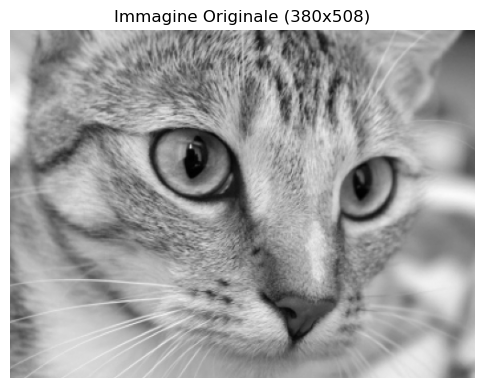

In [234]:
# Inserisci qui il nome del tuo file (assicurati che sia nella stessa cartella del notebook)
filename = 'gatto.bmp'  # Cambia con 'tua_immagine.bmp' se necessario

try:
    image_source = io.imread(filename)
except FileNotFoundError:
    print(f"ERRORE: Non trovo il file '{filename}'. Controlla il nome o la cartella.")
    raise

# Conversione in scala di grigi
# Se l'immagine ha 3 canali (colore), la convertiamo. Se è già grigia, la teniamo così.
if image_source.ndim == 3:
    A_img = rgb2gray(image_source)
else:
    A_img = image_source

# Normalizzazione (sicurezza): portiamo i valori tra 0 e 1 se sono in 0-255
if A_img.max() > 1.0:
    A_img = A_img / 255.0

m, n = A_img.shape

plt.figure(figsize=(6, 6))
plt.imshow(A_img, cmap='gray')
plt.title(f"Immagine Originale ({m}x{n})")
plt.axis('off')
plt.show()

Calcolare la matrice

$$
A_p = \sum_{i=1}^p u_i*v_i^T*σ_i
$$

dove $p ≤ rango(A)$ e la visualizzo

In [235]:
def Ap(U, s, Vt, p):
    S_p = np.diag(s[:p])
    A_p = U[:, :p] @ S_p @ Vt[:p, :]
    return A_p

Calcolare l'errore relativo:

$$ER=\frac{||A-A_p||_2}{||A||_2}$$

In [236]:
def errore_relativo(A, A_p, errors): 
    norm_A = np.linalg.norm(A, 'fro')
    norm_diff = np.linalg.norm(A - A_p, 'fro')
    rel_err = norm_diff / norm_A
    errors.append(rel_err)

Calcolare il fattore di compressione

$$c_p=\frac{1}{p}min(m,n)-1$$

In [237]:
def cp(A, p, compression_factors):
    c_p = (1/p) * min(A.shape) - 1
    compression_factors.append(c_p)

Calcolare e plottare l’ errore relativo e il fattore di compressione al variare
di p.

In [238]:
def plot_results(p_values, errors, compression_factors):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:red'
    ax1.set_xlabel('Valore di p (rango)')
    ax1.set_ylabel('Errore Relativo', color=color)
    ax1.plot(p_values, errors, marker='o', color=color, label='Errore Relativo')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()  # Secondo asse y per il fattore di compressione
    color = 'tab:blue'
    ax2.set_ylabel('Fattore di Compressione (cp)', color=color)
    ax2.plot(p_values, compression_factors, marker='s', linestyle='--', color=color, label='Fattore Compressione')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title("Andamento Errore Relativo e Fattore di Compressione")
    plt.show()

In [239]:
# Fissati alcuni valori di p come richiesto
p_values = [5, 20, 50, 100, 150] 

def svd_compression(A, p_values):
    # Codice standard per SVD (non presente nei file forniti, implementato con numpy)
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    # === 3. COMPRESSIONE E METRICHE AL VARIARE DI p ===
    errors = []
    compression_factors = []

    plt.figure(figsize=(15, 8))

    for i, p in enumerate(p_values):
        if p > min(A.shape):
            continue
            
        # Calcolo della matrice Ap
        # Ap = sum(u_i * v_i^T * sigma_i) per i da 1 a p
        # Implementazione matriciale: U[:, :p] * diag(s[:p]) * Vt[:p, :]
        A_p = Ap(U, s, Vt, p)
        
        # Calcolo errore relativo
        # Formula PDF: ||A - Ap||_2 / ||A||_2
        # Nota: Usiamo la norma Frobenius ('fro').
        errore_relativo(A, A_p, errors)
        
        # Calcolo fattore di compressione
        # Formula PDF: cp = (1/p) * min(m,n) - 1
        cp(A, p, compression_factors)
        
        # Visualizzazione immagine Ap
        plt.subplot(2, 3, i+1) # Adatta griglia in base a len(p_values)
        plt.imshow(A_p, cmap='gray')
        plt.title(f"p={p}\nErr: {errors[-1]:.4f}, Cp: {compression_factors[-1]:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    plot_results(p_values, errors, compression_factors)

Test delle funzioni

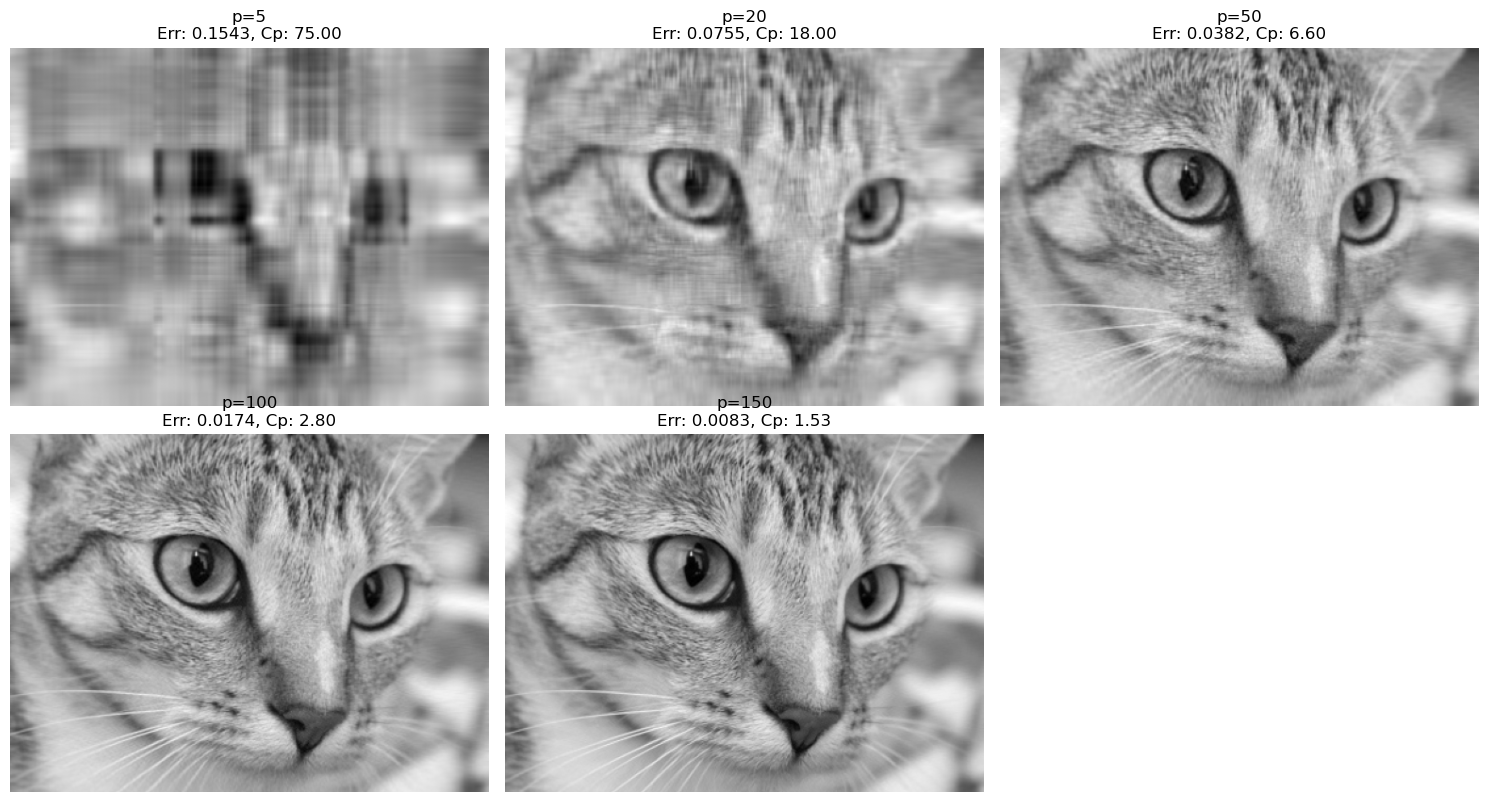

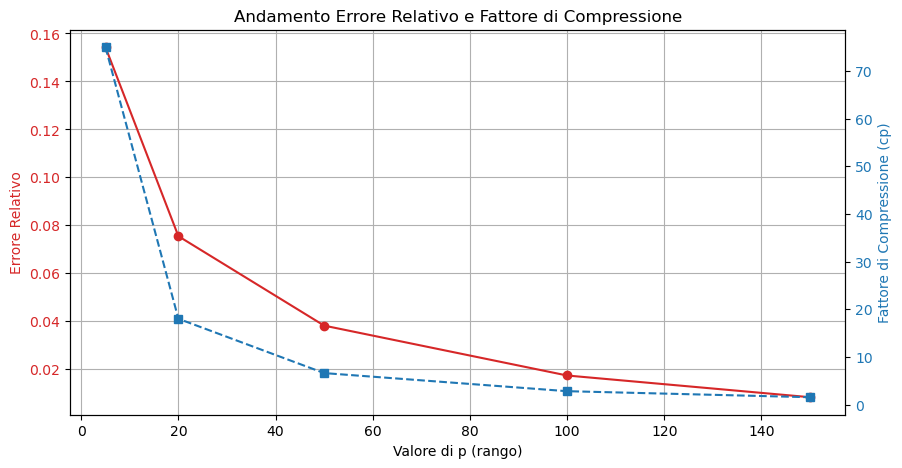

In [240]:
svd_compression(A_img, p_values)



 ### 2. Image deblur




Inclusione della cartella Problemi inversi

In [241]:
from ProblemiInversi import operators, solvers, utilities

Creare un problema test

In [242]:
def stamp_kernel(kernel):
    plt.imshow(kernel, cmap='hot')
    plt.axis('off')
    plt.show()

In [243]:
def stamp_noise_image(A):
    plt.figure(figsize=(6, 6))
    plt.imshow(A, cmap='gray')
    plt.title(f"Immagine con rumore")
    plt.axis('off')
    plt.show()

In [244]:
def prob_test(nl, sigma, x_true):
    # 1. Creazione Operatore di Blur
    k_size = 15
    kernel = utilities.gaussian2d_kernel(k_size, sigma)
    A = operators.ConvolutionOperator(kernel)
    stamp_kernel(kernel)
    # Calcolo immagine sfocata pulita
    b_clean = A(x_true)
    
    # 2. Aggiunta Rumore
    noise = utilities.gaussian_noise(b_clean, nl)
    b_noisy = b_clean + noise
    stamp_noise_image(b_noisy)
    # Calcolo norma del rumore (Delta)
    noise_realization = b_noisy - b_clean
    delta = np.linalg.norm(noise_realization)
    
    print(f"\n--- Livello di Rumore: {nl*100}% (Delta: {delta:.4f}) ---")
    return b_noisy, A, delta

Calcolare la soluzione naive risolvendo il problema di minimi quadrati
con CGLS

In [245]:
def CGLS(b_noisy, x_true, A, max_iter_cgls):
    print("Calcolo soluzione Naive (CGLS)...")
    solver_naive = solvers.CGLS(A) 
    x0 = np.zeros_like(b_noisy)
    x_naive = solver_naive.solve(b_noisy, x0, kmax=max_iter_cgls)
        
    err_naive = utilities.rel_err(x_naive, x_true)
    print(f"-> Naive Error: {err_naive:.4f}")
    return x_naive, err_naive

Calcolare la soluzione regolarizzata con Tikhonov. Calcolare il valore
di λ sia con il principio di Massima Discrepanza che come valore
che minimizza l’errore assoluto fra l’immagine ground truth e la ricostruzione
(su una griglia di valori di λ), visualizzando il grafico
relativo.

In [246]:
def Tik(b_noisy, x_true, A, max_iter_cgls, lambdas_tik, delta, x0):
    print("Calcolo soluzione Tikhonov...")
        
    best_err_tik = float('inf')
    best_lam_tik = 0
    best_x_tik = None
        
    tik_errors = []
    tik_residuals = [] 
    x_tik_disc = None
    best_disc_diff = float('inf')
    lam_disc_tik = 0
        
    L = operators.Identity() 
       
    for lam in lambdas_tik:
        solver_tik = solvers.CGLS(A, L=L, lmbda=lam)
        x_tik = solver_tik.solve(b_noisy, x0, kmax=max_iter_cgls)
          
        # Errore vs GT
        err = utilities.rel_err(x_tik, x_true)
        tik_errors.append(err)
           
        if err < best_err_tik:
            best_err_tik = err
            best_lam_tik = lam
            best_x_tik = x_tik
            
        # Residuo per Discrepanza
        res_norm = np.linalg.norm(A(x_tik) - b_noisy)
        tik_residuals.append(res_norm)
            
        diff = abs(res_norm - delta)
        if diff < best_disc_diff:
            best_disc_diff = diff
            x_tik_disc = x_tik
            lam_disc_tik = lam

    print(f"-> Tikhonov Best (vs GT): Lambda={best_lam_tik:.5f}, Err={best_err_tik:.4f}")
    print(f"-> Tikhonov Discrepancy: Lambda={lam_disc_tik:.5f}, Err={utilities.rel_err(x_tik_disc, x_true):.4f}")
    
    # Ritorna anche l'errore del migliore per il plot
    return best_x_tik, tik_errors, x_tik_disc, best_err_tik

Calcolare la soluzione regolarizzata con Total Variation. Calcolare
il valore di λ come valore che minimizza l’errore assoluto (in norma
2) fra l’immagine ground truth e la ricostruzione (su una griglia di
valori di λ) visualizzando il grafico relativo.

In [247]:
def TV(b_noisy, x_true, A, lambdas_tv, x0):
    print("Calcolo soluzione Total Variation (Gradient Descent)...")
    
    # 1. Configurazione Solver (come da tua richiesta specifica)
    beta = 1e-3
    gd_tv_solver = solvers.GDTotalVariation(A, beta=beta)

    # 2. Parametri Iterativi Fissi
    kmax = 30     # Iterazioni ridotte per contenere la lentezza
    tolf = 1e-8
    tolx = 1e-8
    
    # Variabili per tracciare il migliore
    best_err_tv = float('inf')
    best_lam_tv = 0
    best_x_tv = None
    tv_errors = []
        
    for lam in lambdas_tv:
        # Risoluzione del problema
        # Nota: gd_tv_solver.solve restituisce (x, obj_val, grad_norm)
        # Usiamo x0 passato come argomento (es. b_noisy) per velocizzare un minimo,
        # oppure usa np.zeros_like(b_noisy) se vuoi essere fedele al 100% allo snippet.
        x_tv, _, _ = gd_tv_solver.solve(b_noisy, lam, x0, kmax, tolf, tolx)
            
        # Calcolo errore
        err = utilities.rel_err(x_tv, x_true)
        tv_errors.append(err)
            
        # Controllo se è il risultato migliore finora
        if err < best_err_tv:
            best_err_tv = err
            best_lam_tv = lam
            best_x_tv = x_tv
            
    print(f"-> TV Best (vs GT): Lambda={best_lam_tv:.5f}, Err={best_err_tv:.4f}")
    
    # Restituisce l'immagine migliore e la lista degli errori per il grafico
    return best_x_tv, tv_errors, best_err_tv

Funzione per la visualizzazione

In [248]:
def plot_deblur_results(b_noisy, x_naive, err_naive, 
                 best_x_tik, best_err_tik, x_tik_disc, 
                 best_x_tv, best_err_tv, 
                 lambdas_tik, tik_errors, lambdas_tv, tv_errors, nl, sigma, x_true):
    
    plt.figure(figsize=(15, 5))
    
    titles = ["Dati Rumorosi", "Naive", "Tikhonov (Best)", "Tikhonov (Disc)", "TV (Best)"]
    images = [b_noisy, x_naive, best_x_tik, x_tik_disc, best_x_tv]
    
    # Calcolo errore discrepanza al volo per il titolo
    if x_tik_disc is not None:
        err_disc = utilities.rel_err(x_tik_disc, x_true) 
    else:
        err_disc = 0
    errors = [None, err_naive, best_err_tik, err_disc, best_err_tv]

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        t = titles[i]
        if errors[i] is not None:
            t += f"\nErr: {errors[i]:.3f}"
        plt.title(t)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Plot Curve Errori
    plt.figure(figsize=(8, 4))
    plt.semilogx(lambdas_tik, tik_errors, 'b-o', label='Tikhonov')
    plt.semilogx(lambdas_tv, tv_errors, 'r-s', label='TV')
    plt.axhline(y=err_naive, color='k', linestyle='--', label='Naive Base')
    plt.xlabel('Lambda')
    plt.ylabel('Relative Error')
    plt.title(f'Errore vs Lambda (Sigma={sigma}, Noise={nl})')
    plt.legend()
    plt.grid(True)
    plt.show()

Test

In [249]:
def test(x_true, max_iter_cgls, lambdas_tik, lambdas_tv, sigmas, noise_levels):
    
    for sigma in sigmas:
        print(f"\n{'='*80}")
        print(f"ANALISI CON PSF SIGMA = {sigma}")
        print(f"{'='*80}")
        
        for nl in noise_levels:
            # 1. Genera problema
            b_noisy, A, delta = prob_test(nl, sigma, x_true) 
            # Punto di partenza ottimizzato (b_noisy invece di zero)
            x0_start = b_noisy.copy()
            
            # 2. Esegui Solutori
            x_naive, err_naive = CGLS(b_noisy, x_true, A, max_iter_cgls)
            
            best_x_tik, tik_errors, x_tik_disc, best_err_tik = Tik(
                b_noisy, x_true, A, max_iter_cgls, lambdas_tik, delta, x0_start
            )
            
            best_x_tv, tv_errors, best_err_tv = TV(
                b_noisy, x_true, A, lambdas_tv, x0_start
            )
            
            # 3. Plot
            plot_deblur_results(b_noisy, x_naive, err_naive, 
                         best_x_tik, best_err_tik, x_tik_disc, 
                         best_x_tv, best_err_tv, 
                         lambdas_tik, tik_errors, lambdas_tv, tv_errors, nl, sigma, x_true)


ANALISI CON PSF SIGMA = 1


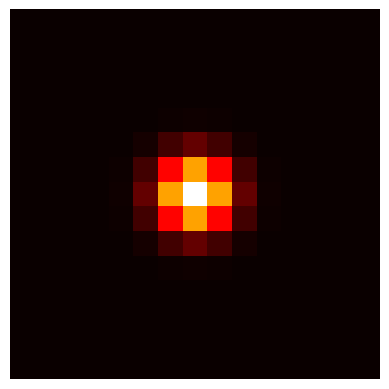

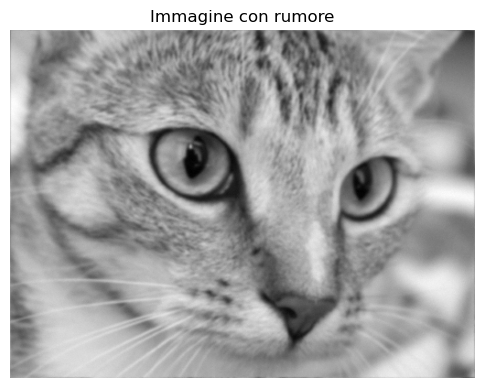


--- Livello di Rumore: 1.0% (Delta: 2.7010) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.3535
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0331
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.0404
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00077, Err=0.0266


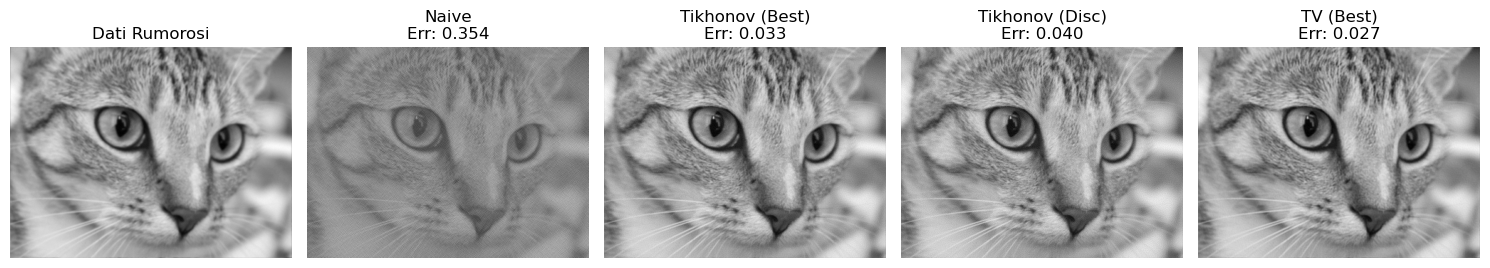

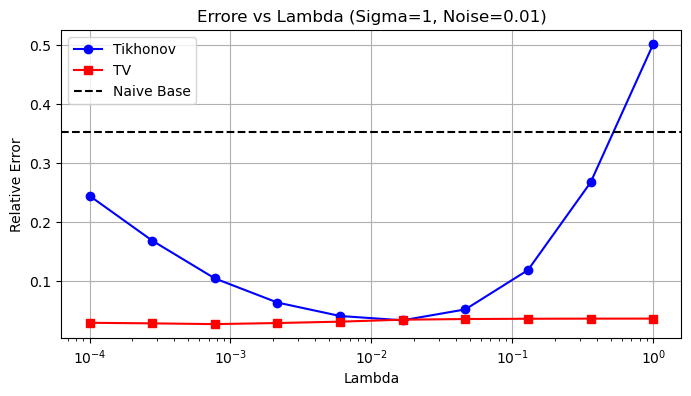

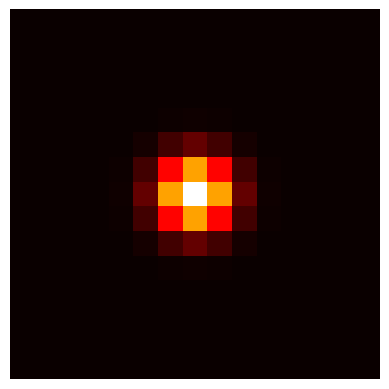

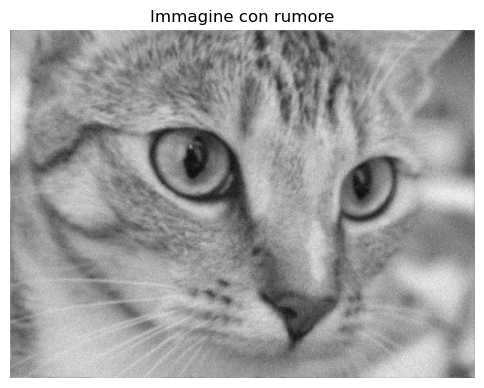


--- Livello di Rumore: 5.0% (Delta: 13.5049) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.7946
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0812
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.1114
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.35938, Err=0.0563


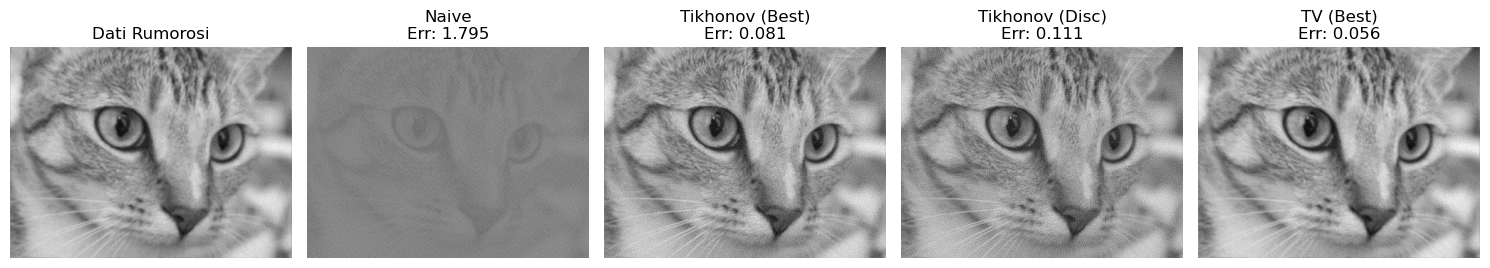

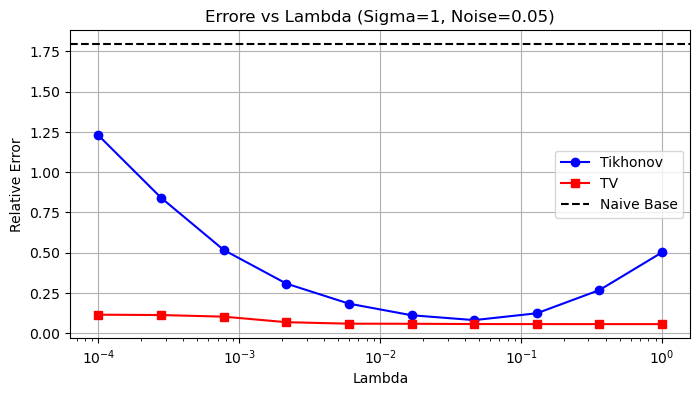

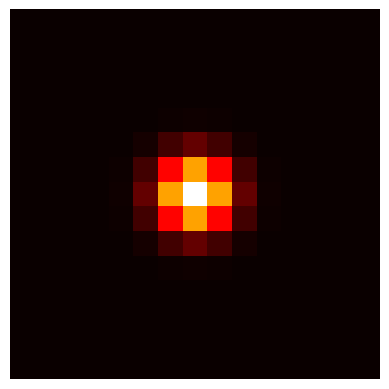

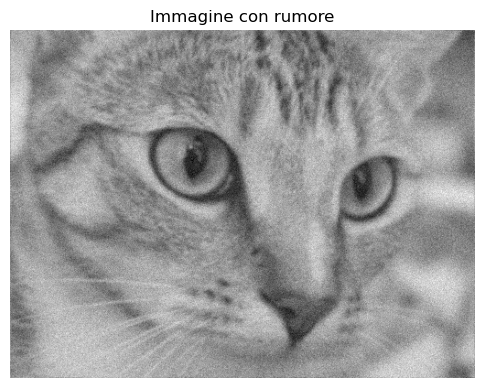


--- Livello di Rumore: 10.0% (Delta: 27.0099) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.6034
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.1372
-> Tikhonov Discrepancy: Lambda=0.04642, Err=0.1372
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.35938, Err=0.0962


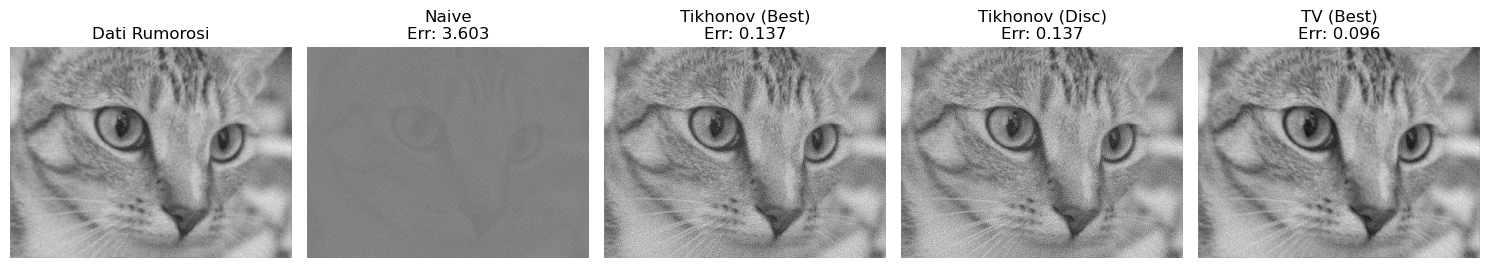

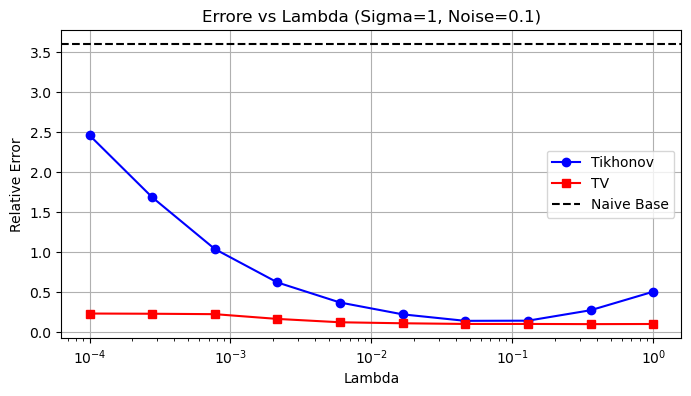


ANALISI CON PSF SIGMA = 3


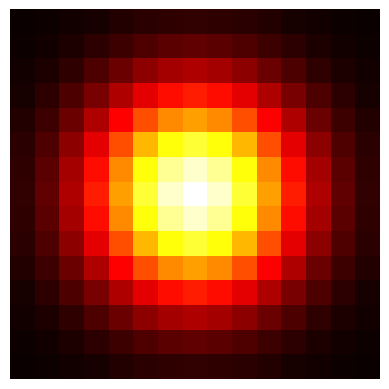

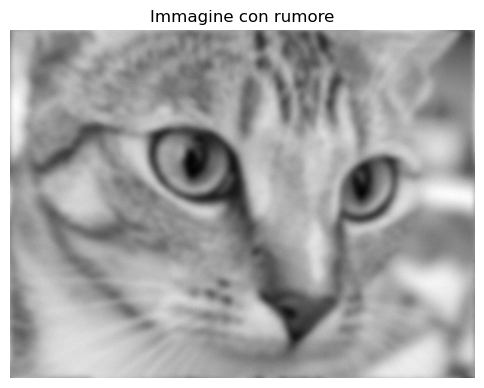


--- Livello di Rumore: 1.0% (Delta: 2.6881) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.2785
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.00215, Err=0.0546
-> Tikhonov Discrepancy: Lambda=0.00215, Err=0.0546
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00010, Err=0.0578


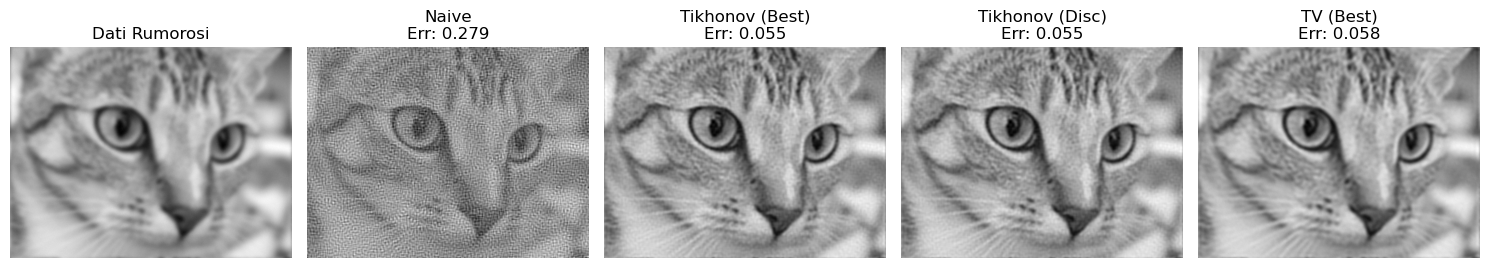

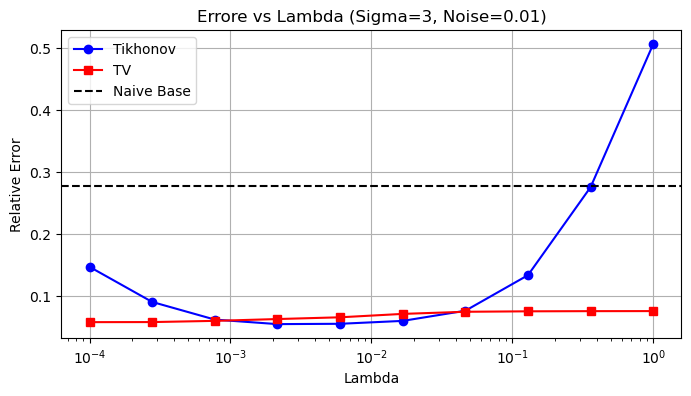

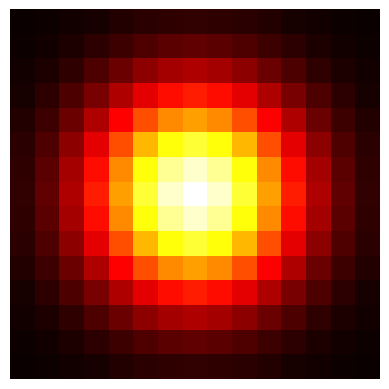

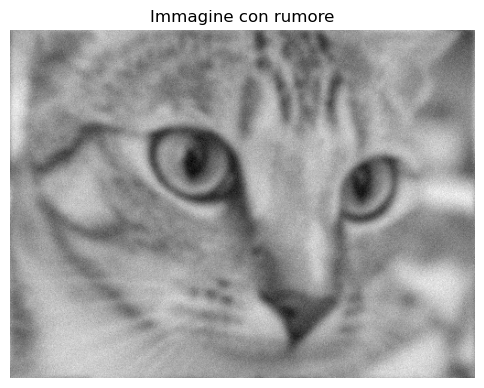


--- Livello di Rumore: 5.0% (Delta: 13.4403) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.5369
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0693
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.0817
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00215, Err=0.0771


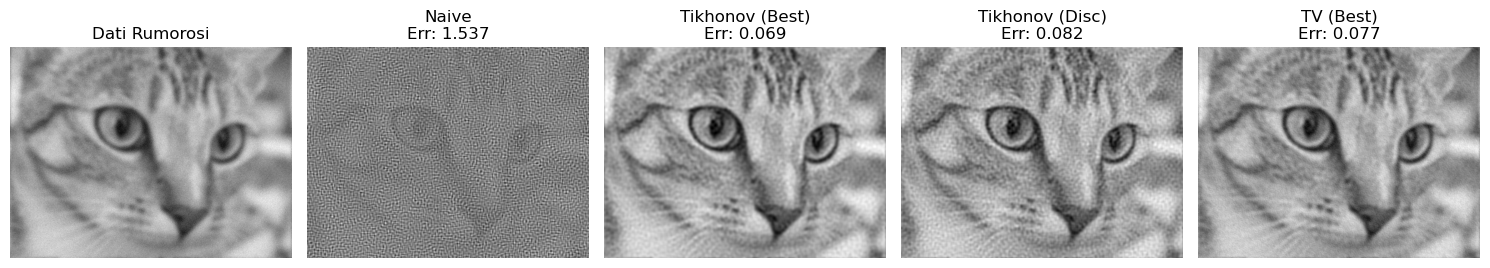

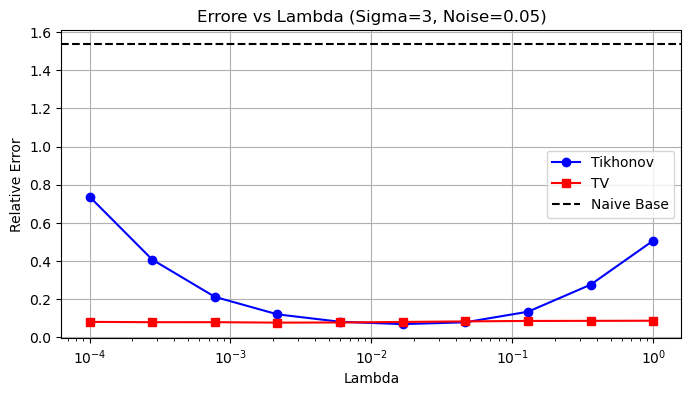

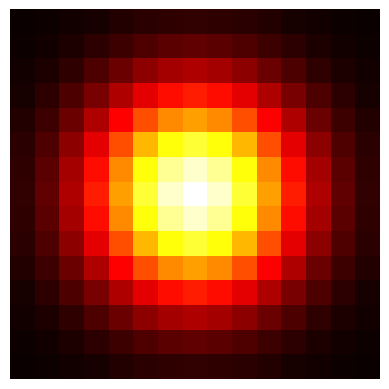

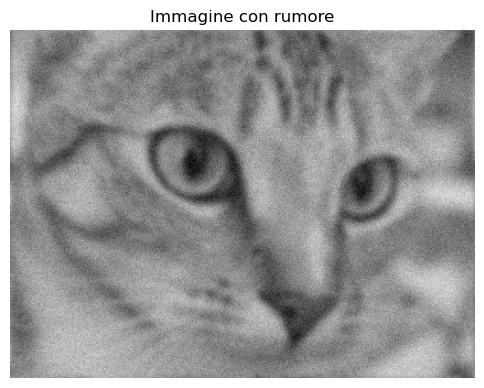


--- Livello di Rumore: 10.0% (Delta: 26.8805) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.1620
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0874
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.0938
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.01668, Err=0.1103


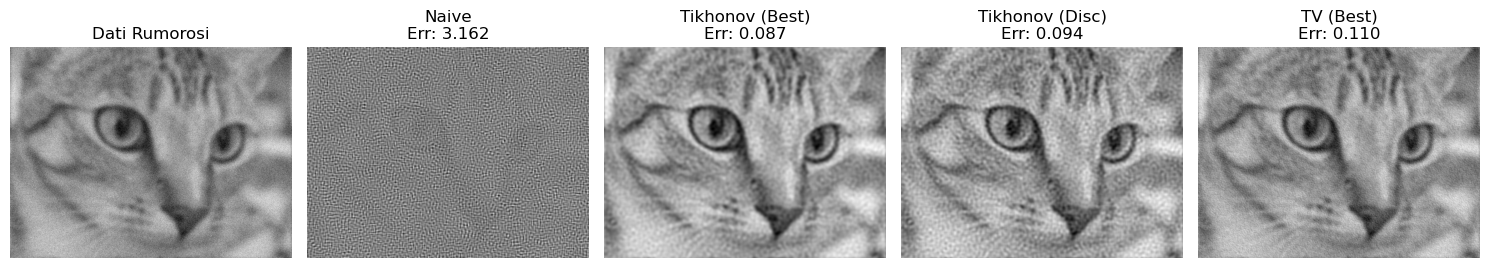

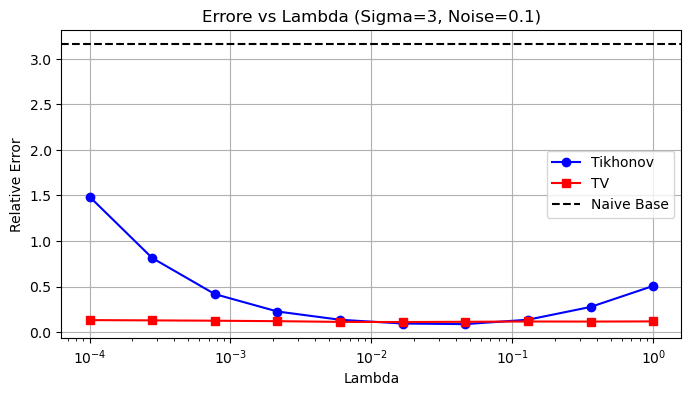


ANALISI CON PSF SIGMA = 5


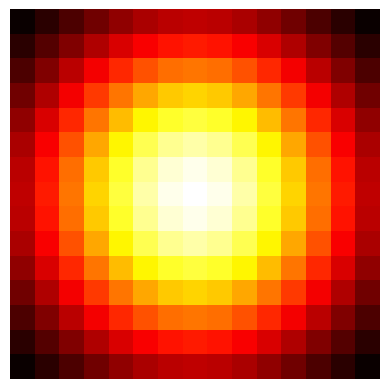

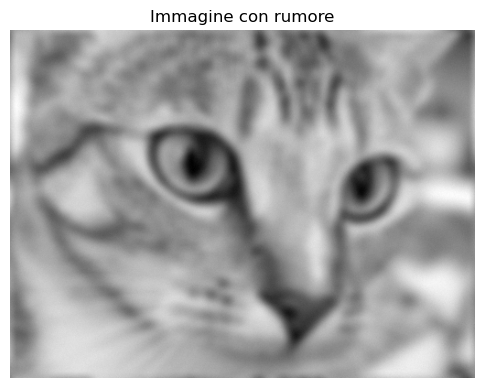


--- Livello di Rumore: 1.0% (Delta: 2.6824) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.2796
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.00599, Err=0.0651
-> Tikhonov Discrepancy: Lambda=0.00215, Err=0.0664
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00010, Err=0.0707


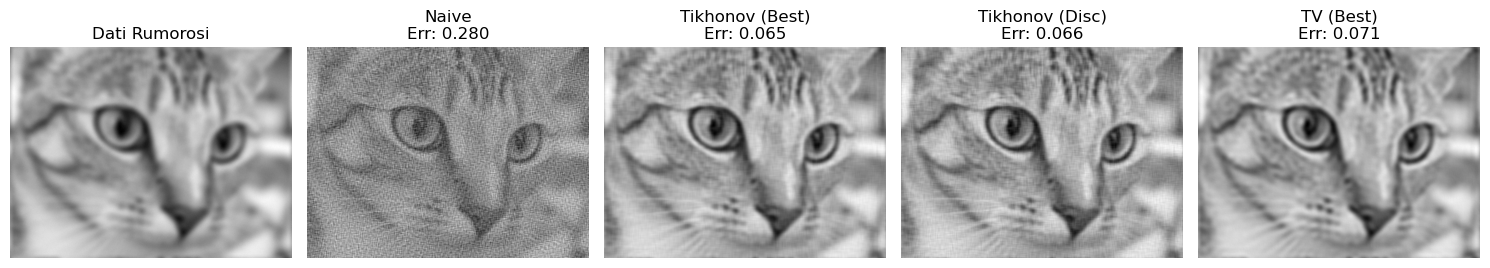

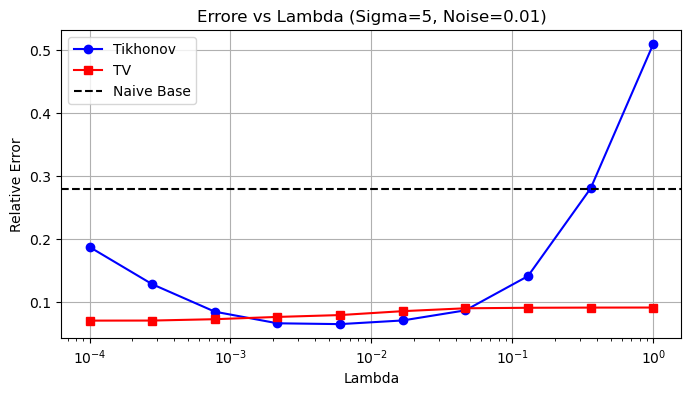

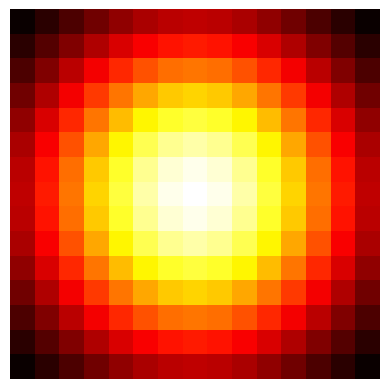

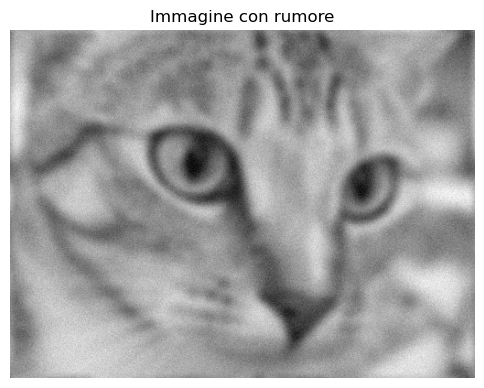


--- Livello di Rumore: 5.0% (Delta: 13.4121) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.5043
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0799
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.1037
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00077, Err=0.0860


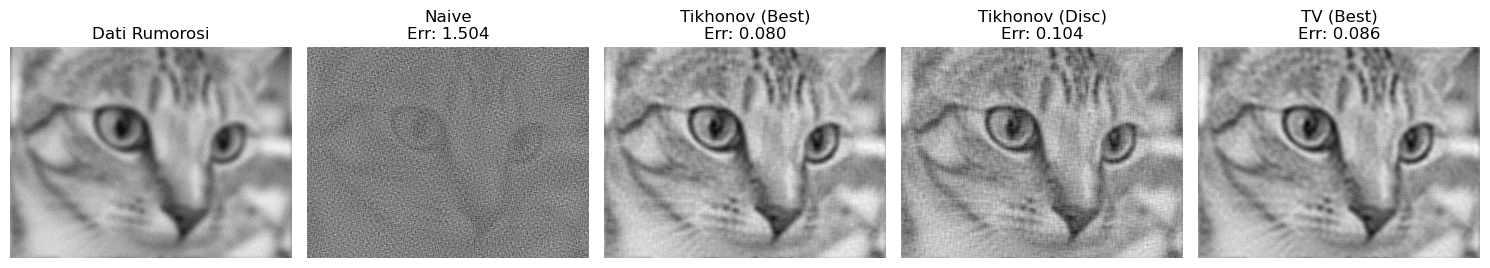

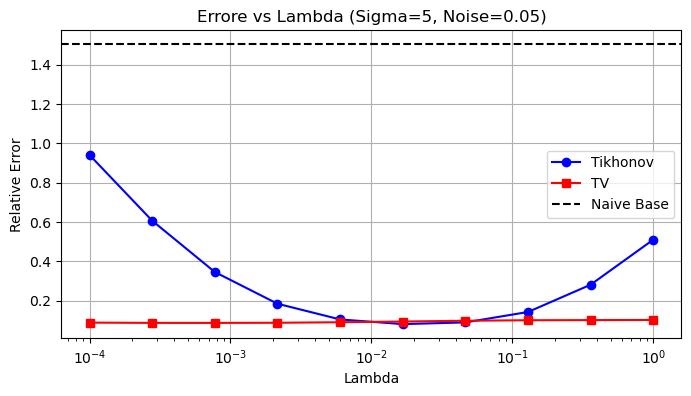

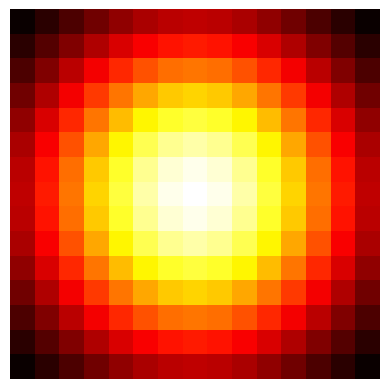

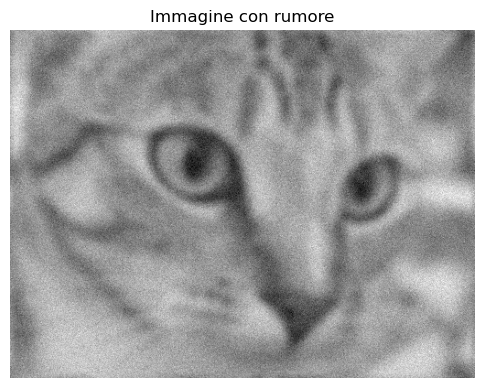


--- Livello di Rumore: 10.0% (Delta: 26.8242) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.0593
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0939
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.1027
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00599, Err=0.1169


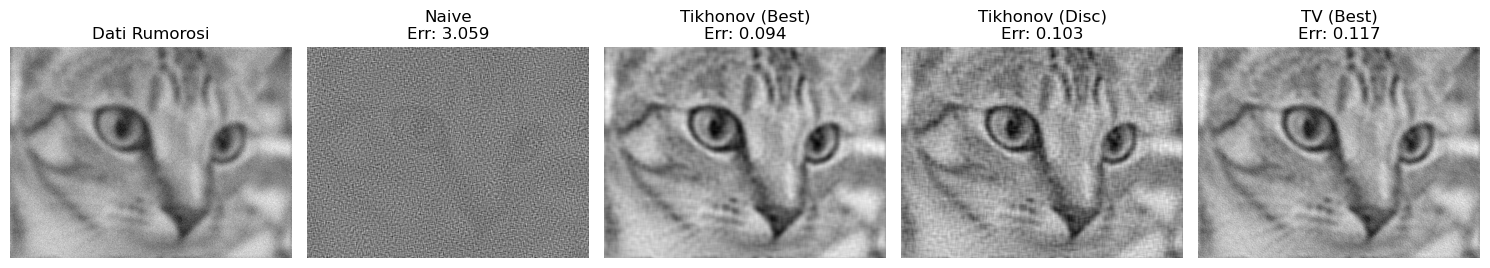

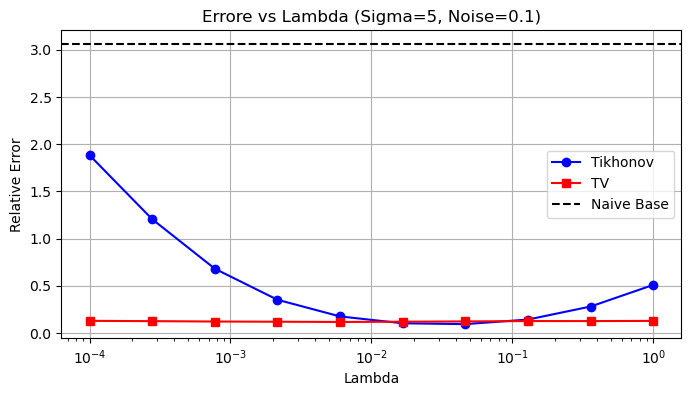

In [250]:
max_iter_cgls = 100
lambdas_tik = np.logspace(-4, 0, 10)
lambdas_tv = np.logspace(-4, 0, 10)
sigmas = [1, 3, 5]
noise_levels = [0.01, 0.05, 0.1]

test(A_img, max_iter_cgls, lambdas_tik, lambdas_tv, sigmas, noise_levels)